In [1]:
from IPython.display import HTML
from tqdm import tqdm
import numpy as np
import random
import math
import cv2
    

from utils import filter_detected, interpolate_missing_data, get_sign_landmarks, display_sign

### In-plane Rotation

In [58]:
def augment_rotate(landmarks:np.ndarray, origin:tuple, angle_range:tuple, num_new_landmarks:int) -> list:
    """
    IN-PLANE ROTATION. All the x,y joint coordinates in each frame are rotated by `num_new_landmarks` random angles between `angle_range[0]` to `angle_range[1]` inclusive. 
    The center of the frame (`origin`) is the point of rotation.
    
    :param landmarks: shape: (nframes, nlandmarks, 3)
    :param origin: x,y coordinates of point of origin for rotation
    :param angle_range: `(min(angle), max(angle))`
    :param num_new_landmarks: number of new independently-rotated variants to generate
    :return: list of new set of landmarks rotated relative to `landmarks` with length = `num_new_landmarks`
    """
    ox, oy = origin
    new_data, angles = [], []
    for _ in range(num_new_landmarks):
        angle = round(math.radians(random.uniform(*angle_range)),3)
        matrix_rotate = np.array([[math.cos(angle), -math.sin(angle)], [math.sin(angle),  math.cos(angle)]])        # 2x2 matrix

        landmarks_2d = landmarks[:,:,:2].transpose(0,2,1).copy()        # (nframes x nlandmarks x 3) -> (nframes x nlandmarks x 2) -> (nframes x 2 x nlandmarks)
        landmarks_3 = landmarks[:,:,2:3]                                # (nframes x nlandmarks x 3) -> (nframes x nlandmarks x 1)

        # rotate(px-ox) + ox | rotate(py-oy) + oy
        landmarks_2d = landmarks_2d - np.array([ox,oy])[:,None]                     # pose_landmarks_2d[:,0,:] - ox | pose_landmarks_2d[:,1,:] - oy
        landmarks_2d_rotated = matrix_rotate @ landmarks_2d                         # (2x2) @ (nframes x 2 x nlandmarks) -> (nframes x 2 x nlandmarks)
        landmarks_2d_rotated = landmarks_2d_rotated.transpose(0,2,1)                # (nframes x 2 x nlandmarks) -> (nframes x nlandmarks x 2)
        landmarks_2d_rotated = landmarks_2d_rotated + np.array([ox, oy])            # landmarks_2d_rotated[:,:,0] + ox | landmarks_2d_rotated[:,:,1] + oy

        new_data.append(np.concatenate([landmarks_2d_rotated, landmarks_3], axis=2))  # (nframes, nlandmarks, 3)
        angles.append(angle)

    return new_data, angles

def augment_squeeze(landmarks:np.ndarray, squeeze_ratio:tuple, num_new_landmarks:int) -> list:
    """
    SQUEEZE. Each frame is squeezed horizontally: independently sampled proportions of the frame's
    width are cut from the left and right edges. y and z coordinates are left untouched. only POSE landmarks are squeezed.

    :param landmarks: shape (nframes, nlandmarks, 3)
    :param squeeze_ratio: (min, max) proportion of the width to randomly cut from each side
    :param num_new_landmarks: number of new independently-squeezed variants to generate
    :return: list of new landmark arrays, length = num_new_landmarks
    """

    new_data, ratios = [], []
    hand_landmarks, pose_landmarks = landmarks[:,:21*2,:], landmarks[:,21*2:,:]

    # (0,0,0) landmarks coords / "missing" joints are restored after the transformation
    is_zero = (pose_landmarks[:,:,0] == 0) & (pose_landmarks[:,:,1] == 0)     # (nframes, nlandmarks) | True/False

    
    for _ in range(num_new_landmarks):
        move_left = round(random.uniform(*squeeze_ratio),3)
        move_right = round(random.uniform(*squeeze_ratio),3)

        # x = 0 -> move_left, x =1 -> 1 - move_right; y & z unaffected
        scale_x = 1 - move_left - move_right
        matrix_squeeze = np.array([[scale_x, 0], [0,1]])        # 2x2 matrix
        translation = np.array([move_left, 0])                  # shift only x

        landmarks_2d = pose_landmarks[:,:,:2].transpose(0,2,1).copy()    # (nframes,2,nlandmarks)
        landmarks_3 = pose_landmarks[:,:,2:3]

        landmarks_2d_squeezed = matrix_squeeze @ landmarks_2d           # (2x2) @ (nframes,2,nlandmarks)
        landmarks_2d_squeezed = landmarks_2d_squeezed.transpose(0,2,1)  # -> (nframes, nlandmarks, 2)
        landmarks_2d_squeezed = landmarks_2d_squeezed + translation     # broadcast add [move_left, 0]

        squeezed = np.concatenate([landmarks_2d_squeezed, landmarks_3], axis=2)     # (nframes, nlandmarks, 3)

        # restore originally-missing (0,0) landmarks
        squeezed[:,:,0][is_zero] = 0
        squeezed[:,:,1][is_zero] = 0

        new_data.append(np.concatenate([hand_landmarks, squeezed], axis=1))
        ratios.append((move_left, move_right))

    return new_data, ratios

### Testing Augmentations

In [59]:
fsl_data = np.load('./dataset/hand_pose_landmarks_105_raw.npy', allow_pickle=True).item()

landmarks = []
for raw_lm in tqdm(fsl_data['data']):
    raw_lm = raw_lm.reshape(-1, 75, 3)

    filtered_lm = filter_detected(raw_lm)
    lmarks = interpolate_missing_data(filtered_lm)

    new_lmarks_rotate, angles = augment_rotate(landmarks=lmarks, origin=(0.5,0.5), angle_range=(1,15),
                                num_new_landmarks=10)
    new_lmarks_squeeze, ratios = augment_squeeze(landmarks=lmarks, squeeze_ratio=(0.01,0.15), num_new_landmarks=10)

    break

  0%|          | 0/2130 [00:00<?, ?it/s]


In [60]:
angles, ratios

([0.249, 0.073, 0.067, 0.178, 0.093, 0.133, 0.117, 0.099, 0.056, 0.091],
 [(0.017, 0.041),
  (0.111, 0.146),
  (0.101, 0.148),
  (0.126, 0.05),
  (0.126, 0.045),
  (0.032, 0.111),
  (0.027, 0.051),
  (0.122, 0.052),
  (0.105, 0.101),
  (0.09, 0.039)])

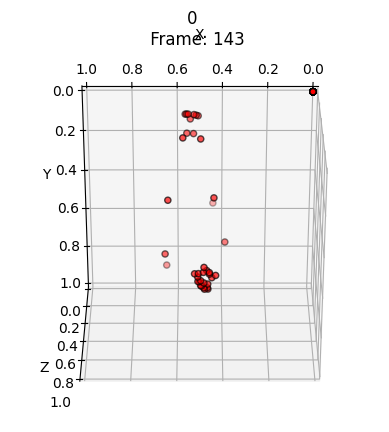

In [4]:
idx = 0
target = fsl_data['target'][0]
anim = display_sign(lmarks[:,:21+21+17,:], target)
HTML(anim.to_html5_video())

In [63]:
angles

[0.249, 0.073, 0.067, 0.178, 0.093, 0.133, 0.117, 0.099, 0.056, 0.091]

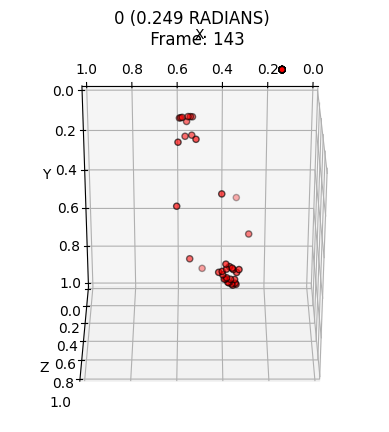

In [ ]:
i = 0
anim = display_sign(new_lmarks_rotate[i][:,:21+21+17,:], cls=f'Class: {target} ({angles[i]} radians)')
HTML(anim.to_html5_video())

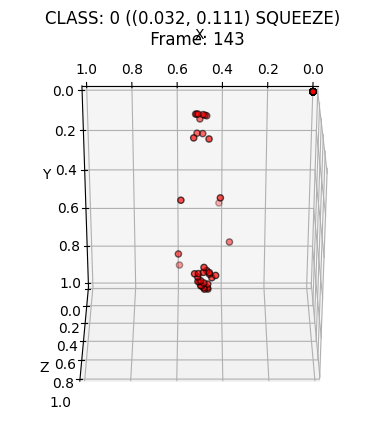

In [65]:
i = 5
anim = display_sign(new_lmarks_squeeze[i][:,:21+21+17,:], cls=f'Class: {target} ({ratios[i]} squeeze)')
HTML(anim.to_html5_video())

### Appending Augmented Landmarks to Dataset

In [66]:
freq = []
for i in range(105):
    freq.append(fsl_data['target'].count(i))

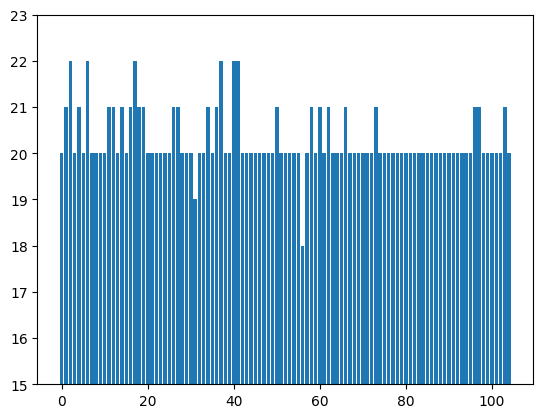

In [72]:
import matplotlib.pyplot as plt

plt.bar(list(range(105)), freq)
plt.ylim([15,23])
plt.show()

In [69]:
np.unique(freq)

array([18, 19, 20, 21, 22])